In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data (1).csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [13]:
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [12]:
df['Дата'] = pd.to_datetime(df['Дата'], dayfirst=True, errors='coerce')

print(df['Дата'].head())

0   2018-04-01
1   2018-04-01
2   2018-04-01
3   2018-04-01
4   2018-04-01
Name: Дата, dtype: datetime64[ns]


Сгруппируйте данные по дате, посчитайте количество продаж

In [11]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество продаж')

print(grouped_df.head())


        Дата  Количество продаж
0 2018-01-02               1521
1 2018-01-03               1387
2 2018-01-04               1455
3 2018-01-05               1481
4 2018-01-06               1467


Вывести несколько первых строк сгруппированных данных

Нарисуйте график продаж у `grouped_df`

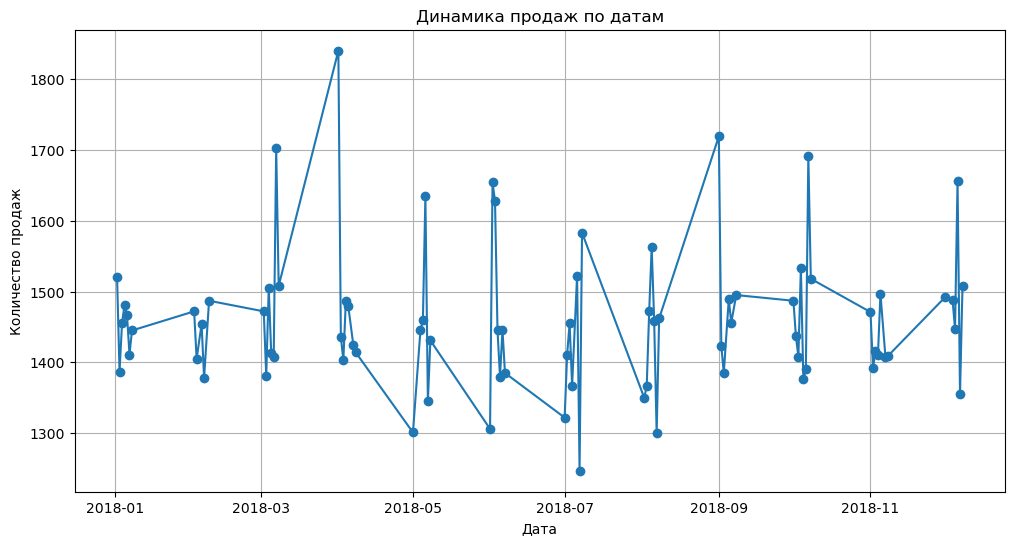

In [14]:
plt.figure(figsize=(12,6))
plt.plot(grouped_df['Дата'], grouped_df['Количество продаж'], marker='o')
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
На графике видно, что продажи имеют колебания во времени. есть периоды с ростом активности в середине месяца спад а в конце пик потомучто акции и распродажи

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [15]:
max_outlier = grouped_df.loc[grouped_df['Количество продаж'].idxmax()]
print("Максимальный выброс:")
print(max_outlier)

Максимальный выброс:
Дата                 2018-04-01 00:00:00
Количество продаж                   1840
Name: 19, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [17]:
df['Месяц'] = df['Дата'].dt.month
df['День недели'] = df['Дата'].dt.day_name(locale='ru_RU')

filtered = df[
    (df['Месяц'].isin([6, 7, 8])) &
    (df['День недели'] == 'среда') &
    (df['Склад'] == 3)
]

top_item = (
    filtered.groupby('Номенклатура')['Количество']
    .sum()
    .reset_index()
    .sort_values('Количество', ascending=False)
    .head(1)
)

print("Топовый товар по средам за летние месяцы на складе №3:")
print(top_item)

Топовый товар по средам за летние месяцы на складе №3:
Empty DataFrame
Columns: [Номенклатура, Количество]
Index: []


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [60]:
weather = pd.read_csv('weather.csv', encoding='utf-8', delimiter=';', skiprows=6)

weather['Местное время в Астане'] = pd.to_datetime(weather['Местное время в Астане'], dayfirst=True, errors='coerce')

weather['Дата'] = weather['Местное время в Астане'].dt.date

weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

weather_daily = weather.groupby('Дата', as_index=False)['T'].mean()

print("Средняя температура за день:")
print(weather_daily.head())


Средняя температура за день:
         Дата        T
0  2018-01-04 -14.0750
1  2018-01-05 -16.8625
2  2018-01-06 -13.3000
3  2018-01-07 -12.7500
4  2018-01-08 -15.4125


In [81]:
import pandas as pd
weather_df['Дата'] = pd.to_datetime(weather_df['Дата'], dayfirst=True)
print(weather_df['Дата'].dtype)

datetime64[ns]


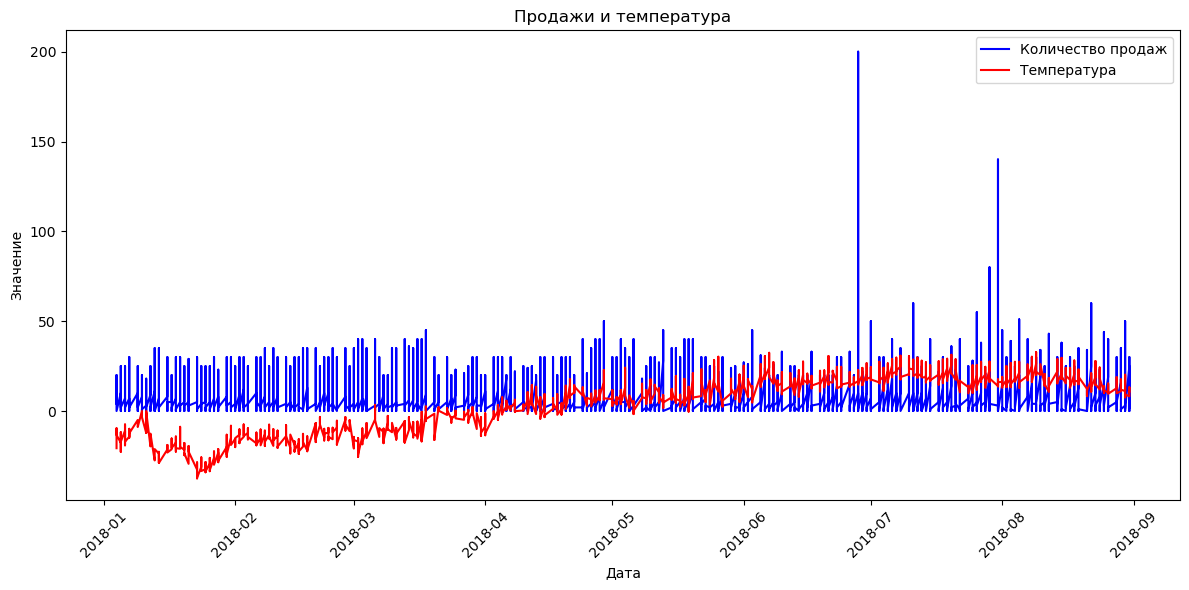

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(merged_df['Дата'], merged_df['Количество'], label='Количество продаж', color='blue')

plt.plot(merged_df['Дата'], merged_df['T'], label='Температура', color='red')

# Подписи
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.title('Продажи и температура')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()